In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import datetime

In [ ]:
# Load the dataset
file_path = "/content/NCRB_CII_2018_State_Table9A.3.csv"
df = pd.read_csv(file_path)

# Display basic information about the dataset
df.info(), df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 25 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   S. No                                         39 non-null     object 
 1   Category                                      39 non-null     object 
 2   State/UT                                      39 non-null     object 
 3   Personal Revenge                              39 non-null     float64
 4   Anger                                         39 non-null     float64
 5   Fraud                                         39 non-null     float64
 6   Extortion                                     39 non-null     float64
 7   Causing Disrepute                             39 non-null     float64
 8   Prank                                         39 non-null     float64
 9   Sexual Exploitation                           39 non-null     float

(None,
   S. No Category           State/UT  Personal Revenge  Anger  Fraud  \
 0     1    State     Andhra Pradesh              34.0   26.0  733.0   
 1     2    State  Arunachal Pradesh               0.0    0.0    2.0   
 2     3    State              Assam             239.0   46.0  389.0   
 3     4    State              Bihar               5.0    8.0  351.0   
 4     5    State       Chhattisgarh               0.0    1.0   23.0   
 
    Extortion  Causing Disrepute  Prank  Sexual Exploitation  ...  \
 0       45.0                7.0    0.0                 92.0  ...   
 1        0.0                0.0    0.0                  0.0  ...   
 2      153.0              234.0    0.0                113.0  ...   
 3        2.0                0.0    0.0                  8.0  ...   
 4        2.0               25.0    0.0                 21.0  ...   
 
    Inciting Hate against Country  Disrupt Public Service  \
 0                            1.0                     1.0   
 1                   

In [ ]:
# Renaming columns for better readability
df.rename(columns={
    "S. No (Col.1)": "S_No",
    "Category (Col.2)": "Category",
    "State/UT (Col.3)": "State_UT",
    "Personal Revenge (Col.4)": "Personal_Revenge",
    "Anger (Col.5)": "Anger",
    "Fraud (Col.6)": "Fraud",
    "Extortion (Col.7)": "Extortion",
    "Causing Disrepute (Col.8)": "Causing_Disrepute",
    "Prank (Col.9)": "Prank",
    "Sexual Exploitation (Col.10)": "Sexual_Exploitation",
    "Political Motives (Col.11)": "Political_Motives",
    "Terrorist Activities (Col.12= Col.13+Col.14+Col.15)": "Terrorist_Activities",
    "Terrorist Activities - Terrorist Recruitment (Col.13)": "Terrorist_Recruitment",
    "Terrorist Activities - Terrorist Funding (Col.14)": "Terrorist_Funding",
    "Terrorist Activities - Others (Col.15)": "Terrorist_Others",
    "Inciting Hate against Country (Col.16)": "Inciting_Hate",
    "Disrupt Public Service (Col.17)": "Disrupt_Public_Service",
    "Sale Purchase Illegal Drugs (Col.18)": "Illegal_Drug_Sale",
    "Developing own Business (Col.19)": "Developing_Business",
    "Spreading Piracy (Col.20)": "Spreading_Piracy",
    "Psycho or Pervert (Col.21)": "Psycho_Pervert",
    "Steal Information (Col.22)": "Steal_Information",
    "Abetment to Suicide (Col.23)": "Abetment_to_Suicide",
    "Others (Col.24)": "Others",
    "Total (Col.25=Col.1+Col.2+Col.3+Col.4Col.5+Col.6+Col.7+Col.8+Col.9+Col.10+Col.11+Col.12+Col.15+Col.16+Col.17+Col.18+Col.19+Col.20+Col.21+Col.22+Col.23+Col.24": "Total"
}, inplace=True)

# Checking the updated column names
df.head()


,S. No,Category,State/UT,Personal Revenge,Anger,Fraud,Extortion,Causing Disrepute,Prank,Sexual Exploitation,...,Inciting Hate against Country,Disrupt Public Service,Sale purchase Illegal drugs,Developing own business,Spreading Piracy,Psycho or Pervert,Steal Information,Abetment to Suicide,Others,Total
0,1,State,Andhra Pradesh,34.0,26.0,733.0,45.0,7.0,0.0,92.0,...,1.0,1.0,0.0,2.0,14.0,2.0,0.0,1.0,236.0,1207.0
1,2,State,Arunachal Pradesh,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,7.0
2,3,State,Assam,239.0,46.0,389.0,153.0,234.0,0.0,113.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,832.0,2022.0
3,4,State,Bihar,5.0,8.0,351.0,2.0,0.0,0.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,374.0
4,5,State,Chhattisgarh,0.0,1.0,23.0,2.0,25.0,0.0,21.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,61.0,139.0


In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]


,0
S. No,1
Category,1
State/UT,1
Personal Revenge,1
Anger,1
Fraud,1
Extortion,1
Causing Disrepute,1
Prank,1
Sexual Exploitation,1


In [ ]:
df_cleaned = df.dropna()
df_cleaned = df_cleaned.reset_index(drop=True)

print(df_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 25 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   S. No                                         39 non-null     object 
 1   Category                                      39 non-null     object 
 2   State/UT                                      39 non-null     object 
 3   Personal Revenge                              39 non-null     float64
 4   Anger                                         39 non-null     float64
 5   Fraud                                         39 non-null     float64
 6   Extortion                                     39 non-null     float64
 7   Causing Disrepute                             39 non-null     float64
 8   Prank                                         39 non-null     float64
 9   Sexual Exploitation                           39 non-null     float

In [ ]:
df_cleaned = df.dropna(axis=1)

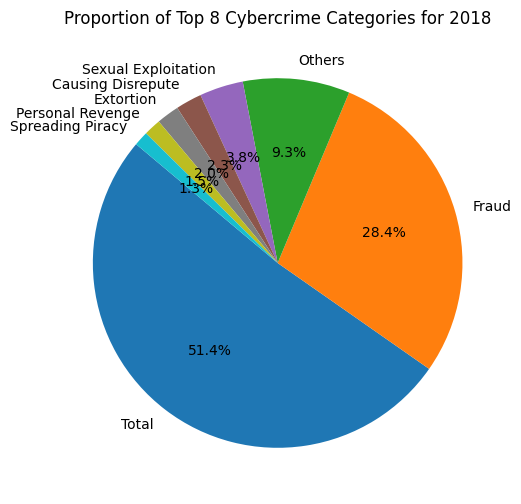

In [ ]:
# Summing up cybercrime types across all states
crime_sums = df.iloc[:, 3:].sum().sort_values(ascending=False)

# Plot pie chart for top 10 cybercrime categories
plt.figure(figsize=(15, 6))
crime_sums[:8].plot(kind="pie", autopct="%1.1f%%", cmap="tab10", startangle=140)
plt.ylabel("")
plt.title("Proportion of Top 8 Cybercrime Categories for 2018")
plt.show()


<ipython-input-8-009287abf618>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_sorted["Total"], y=df_sorted["State/UT"], palette="viridis")


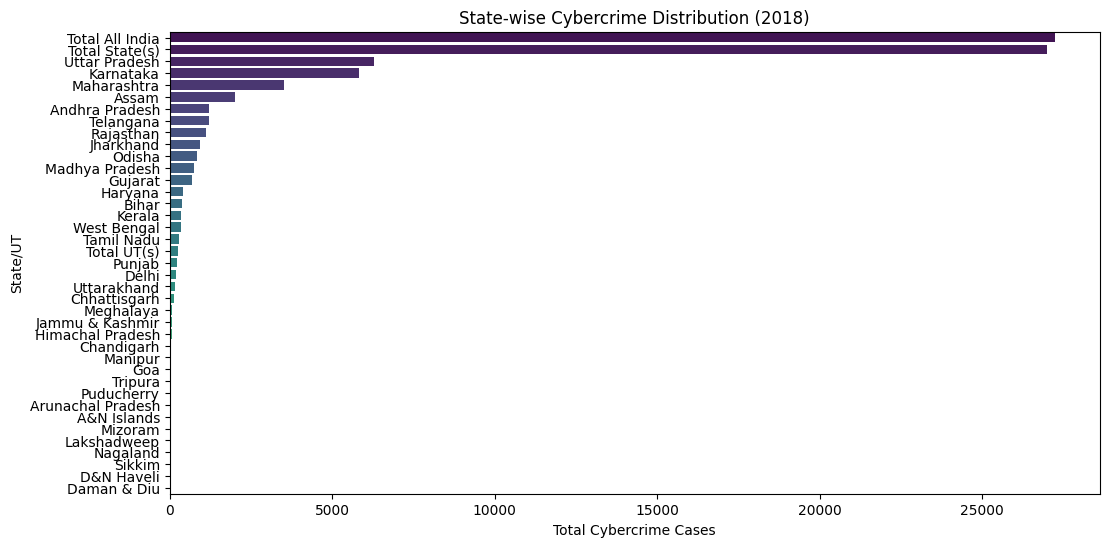

In [ ]:
df_sorted = df.sort_values(by="Total", ascending=False)

# Plotting the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=df_sorted["Total"], y=df_sorted["State/UT"], palette="viridis")
plt.xlabel("Total Cybercrime Cases")
plt.ylabel("State/UT")
plt.title("State-wise Cybercrime Distribution (2018)")
plt.show()

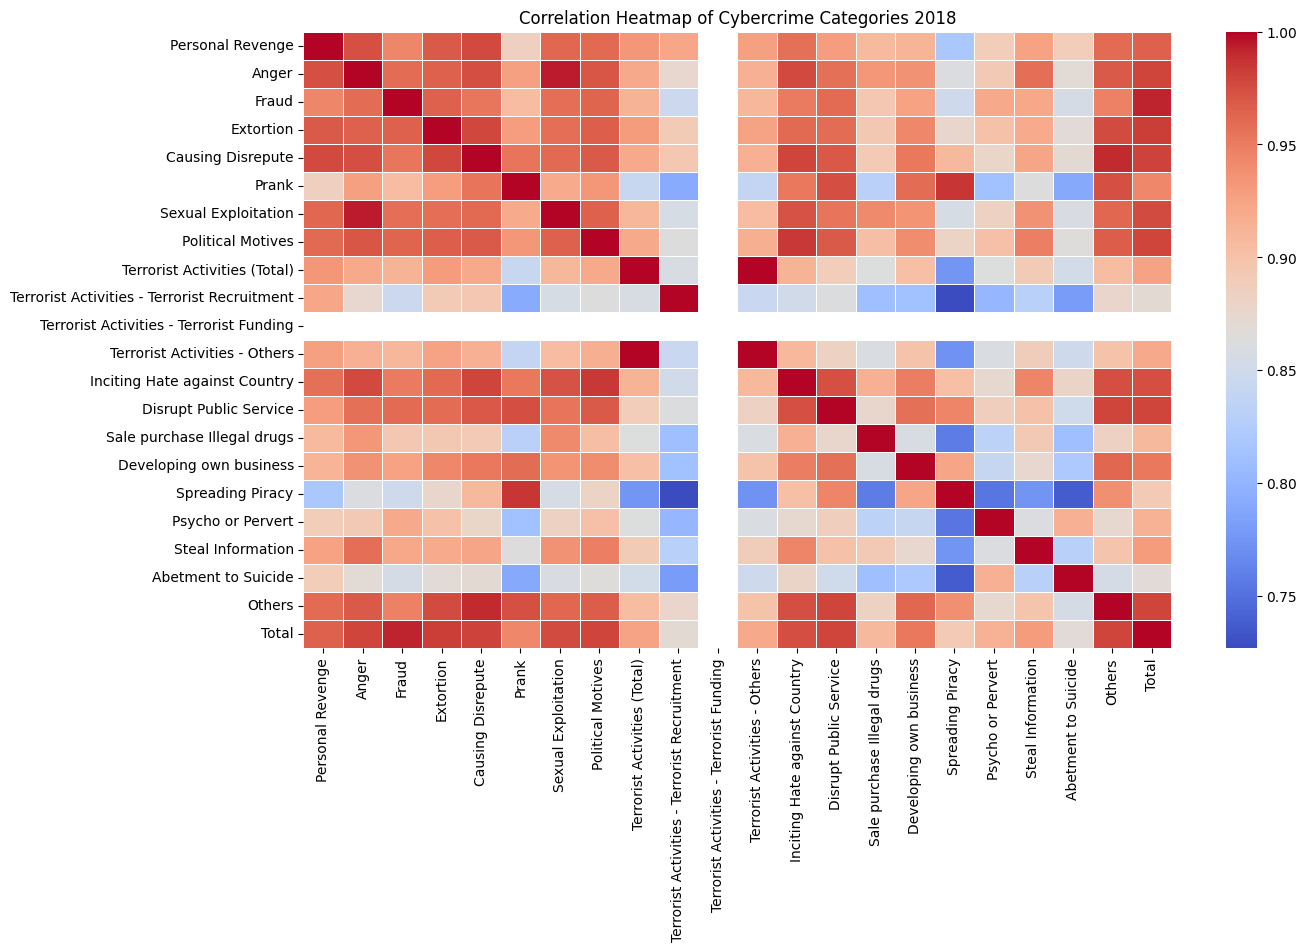

In [ ]:
# Compute correlation matrix
plt.figure(figsize=(14, 8))
corr_matrix = df.iloc[:, 3:].corr()  # Exclude non-numeric columns

# Plot heatmap
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Cybercrime Categories 2018")
plt.show()


<Figure size 1400x600 with 0 Axes>

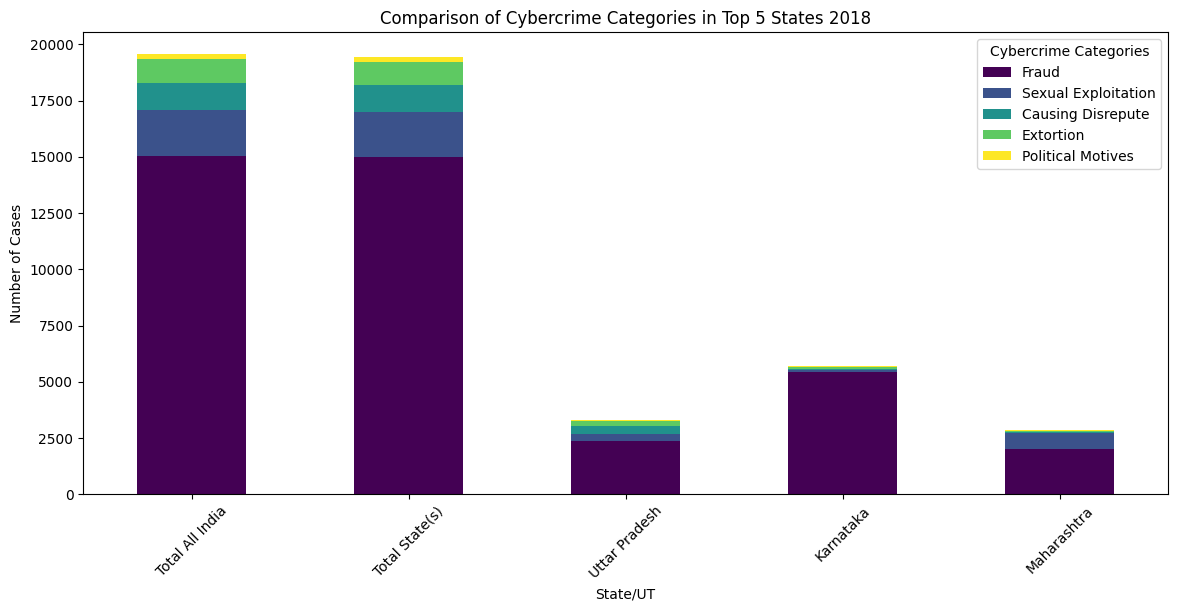

In [ ]:
# Selecting top 5 states with highest cybercrimes for visualization clarity
top_states = df.nlargest(5, "Total")

# Plot stacked bar chart
plt.figure(figsize=(14, 6))
top_states.set_index("State/UT")[["Fraud", "Sexual Exploitation", "Causing Disrepute", "Extortion", "Political Motives"]].plot(kind="bar", stacked=True, colormap="viridis", figsize=(14,6))

plt.xlabel("State/UT")
plt.ylabel("Number of Cases")
plt.title("Comparison of Cybercrime Categories in Top 5 States 2018")
plt.legend(title="Cybercrime Categories")
plt.xticks(rotation=45)
plt.show()


<Figure size 1000x600 with 0 Axes>

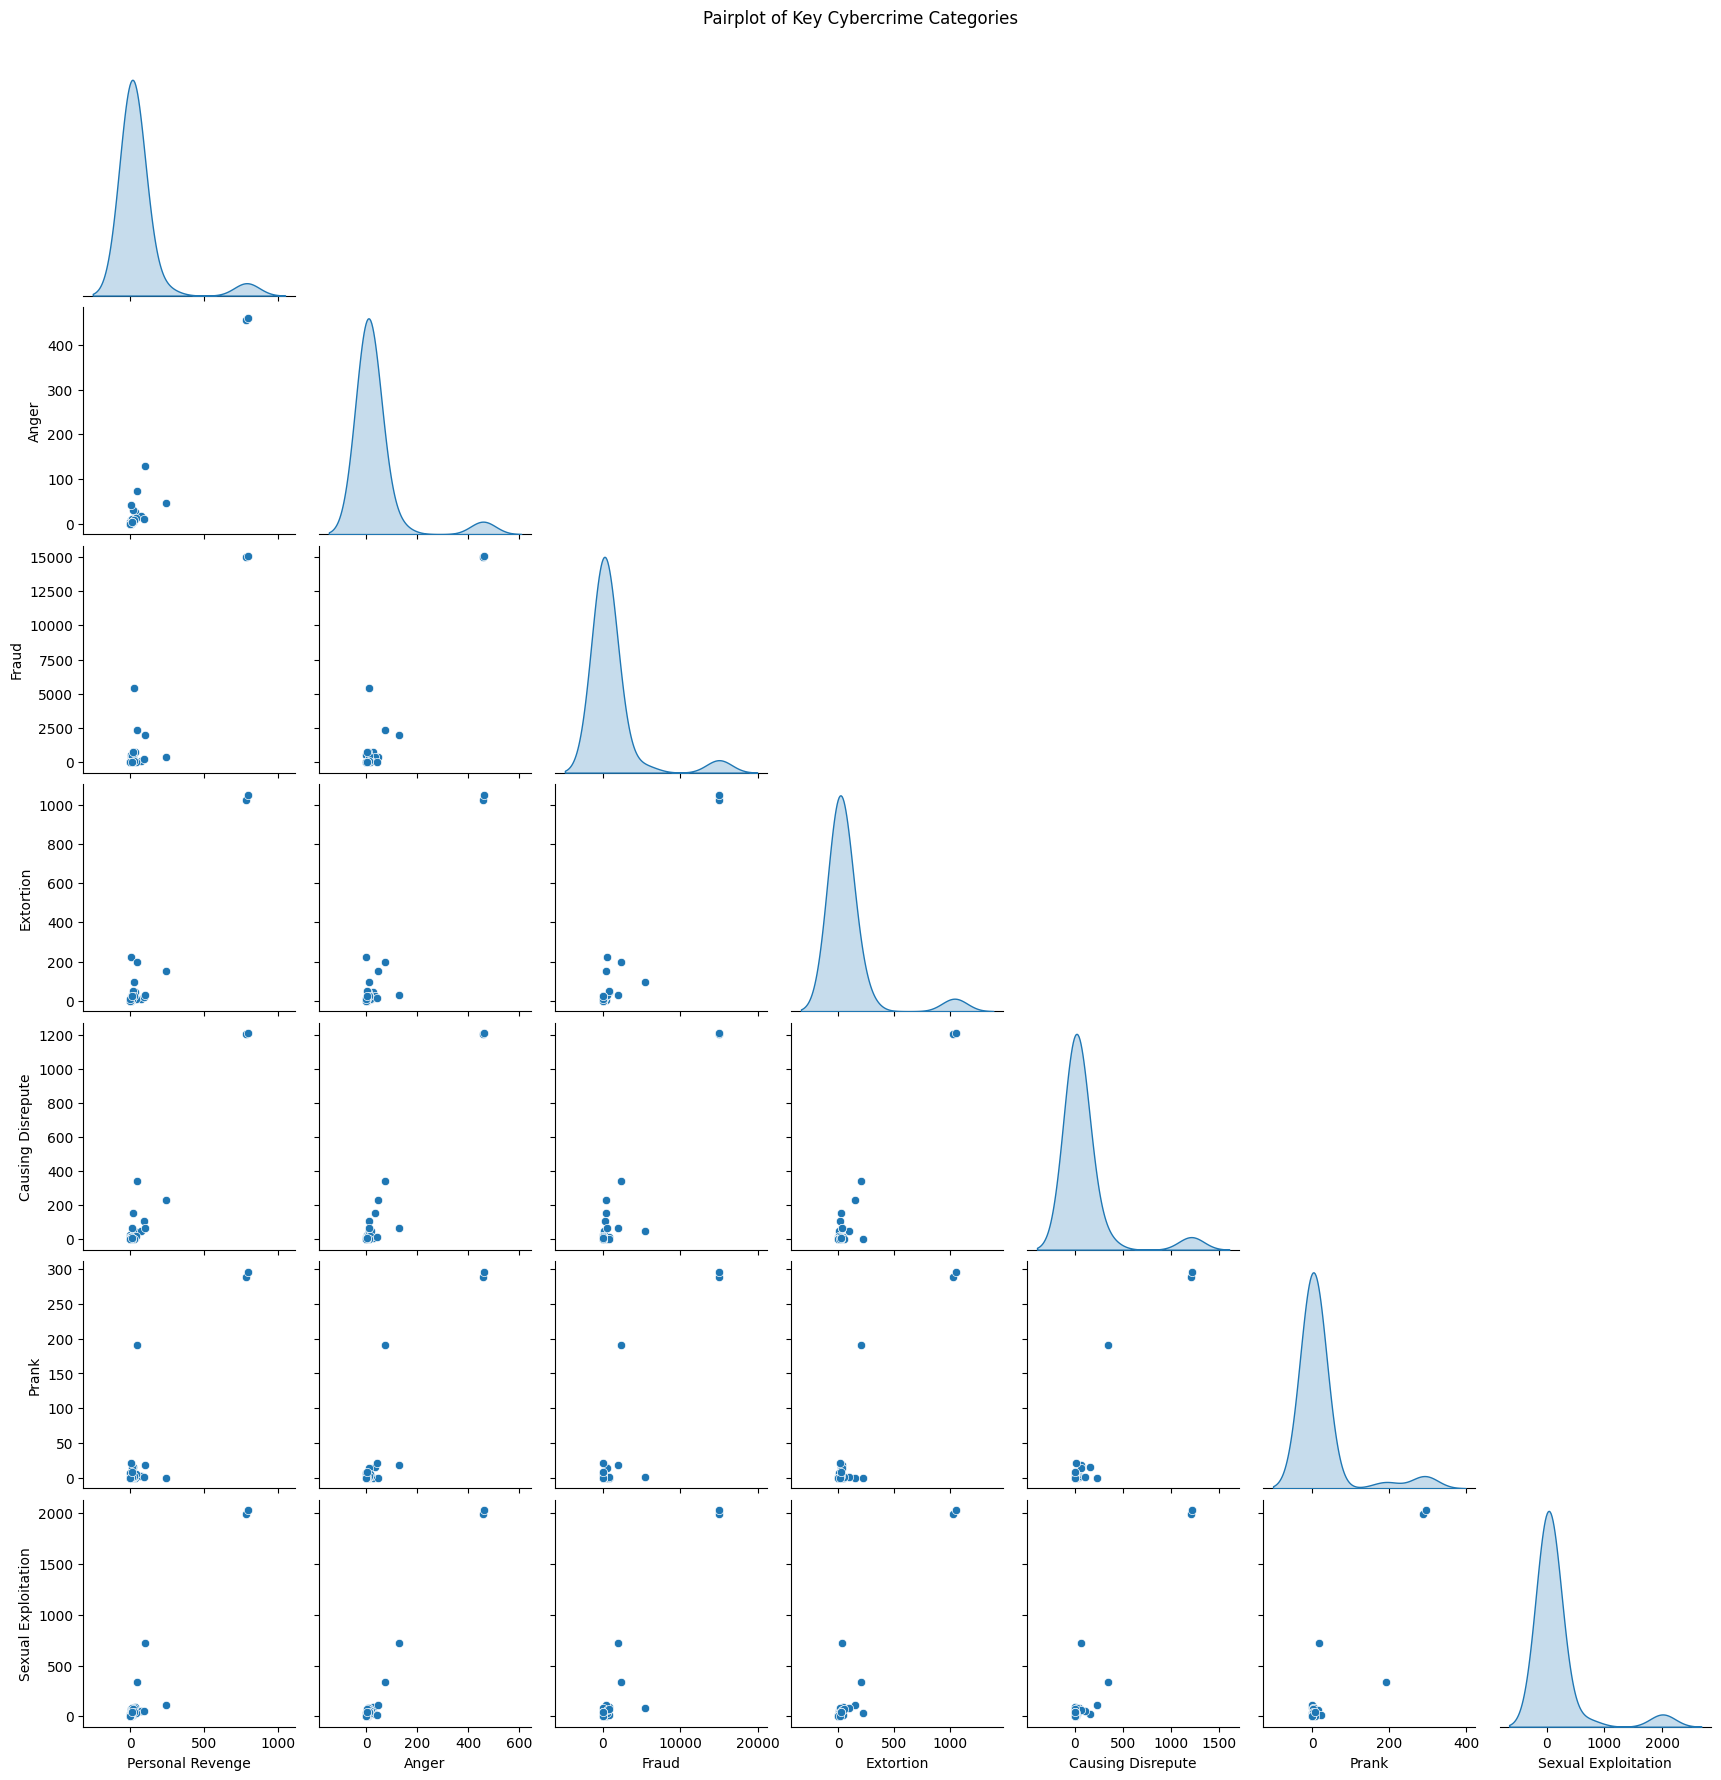

In [ ]:
# Pairplot to visualize relationships between different cybercrime categories
plt.figure(figsize=(10, 6))
sns.pairplot(df.iloc[:, 3:10], diag_kind="kde", corner=True)  # Selecting a subset for clarity
plt.suptitle("Pairplot of Key Cybercrime Categories", y=1.02)
plt.show()


In [ ]:
# Load the dataset
file_path = "/content/NCRB_CII-2019_Table_9A.3.csv"
df = pd.read_csv(file_path)

# Display basic information about the dataset
df.info(), df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 24 columns):
 #   Column                                               Non-Null Count  Dtype 
---  ------                                               --------------  ----- 
 0   Category                                             39 non-null     object
 1   State/UT                                             39 non-null     object
 2   Personal Revenge                                     39 non-null     int64 
 3   Anger                                                39 non-null     int64 
 4   Fraud                                                39 non-null     int64 
 5   Extortion                                            39 non-null     int64 
 6   Causing Disrepute                                    39 non-null     int64 
 7   Prank                                                39 non-null     int64 
 8   Sexual Exploitation                                  39 non-null     int64 
 9   P

(None,
   Category           State/UT  Personal Revenge  Anger  Fraud  Extortion  \
 0    State     Andhra Pradesh                16     17   1211         28   
 1    State  Arunachal Pradesh                 2      2      0          1   
 2    State              Assam               555    263    243        518   
 3    State              Bihar                27      7    844        109   
 4    State       Chhattisgarh                 2      1     47          2   
 
    Causing Disrepute  Prank  Sexual Exploitation  Political Motives  ...  \
 0                  4      5                   84                 88  ...   
 1                  0      0                    0                  0  ...   
 2                 33     14                  289                 16  ...   
 3                  0      5                    8                  0  ...   
 4                 25      0                   30                  5  ...   
 
    Inciting Hate against Country  Disrupt Public Service  \
 0  

In [ ]:
# Renaming columns for better readability
df.rename(columns={
    "S. No (Col.1)": "S_No",
    "Category (Col.2)": "Category",
    "State/UT (Col.3)": "State_UT",
    "Personal Revenge (Col.4)": "Personal_Revenge",
    "Anger (Col.5)": "Anger",
    "Fraud (Col.6)": "Fraud",
    "Extortion (Col.7)": "Extortion",
    "Causing Disrepute (Col.8)": "Causing_Disrepute",
    "Prank (Col.9)": "Prank",
    "Sexual Exploitation (Col.10)": "Sexual_Exploitation",
    "Political Motives (Col.11)": "Political_Motives",
    "Terrorist Activities (Col.12= Col.13+Col.14+Col.15)": "Terrorist_Activities",
    "Terrorist Activities - Terrorist Recruitment (Col.13)": "Terrorist_Recruitment",
    "Terrorist Activities - Terrorist Funding (Col.14)": "Terrorist_Funding",
    "Terrorist Activities - Others (Col.15)": "Terrorist_Others",
    "Inciting Hate against Country (Col.16)": "Inciting_Hate",
    "Disrupt Public Service (Col.17)": "Disrupt_Public_Service",
    "Sale Purchase Illegal Drugs (Col.18)": "Illegal_Drug_Sale",
    "Developing own Business (Col.19)": "Developing_Business",
    "Spreading Piracy (Col.20)": "Spreading_Piracy",
    "Psycho or Pervert (Col.21)": "Psycho_Pervert",
    "Steal Information (Col.22)": "Steal_Information",
    "Abetment to Suicide (Col.23)": "Abetment_to_Suicide",
    "Others (Col.24)": "Others",
    "Total (Col.25=Col.1+Col.2+Col.3+Col.4Col.5+Col.6+Col.7+Col.8+Col.9+Col.10+Col.11+Col.12+Col.15+Col.16+Col.17+Col.18+Col.19+Col.20+Col.21+Col.22+Col.23+Col.24": "Total"
}, inplace=True)

# Checking the updated column names
df.head()


,Category,State/UT,Personal Revenge,Anger,Fraud,Extortion,Causing Disrepute,Prank,Sexual Exploitation,Political Motives,...,Inciting Hate against Country,Disrupt Public Service,Sale purchase illegal drugs,Developing own business,Spreading Piracy,Psycho or Pervert,Steal Information,Abetment to Suicide,Others,Total
0,State,Andhra Pradesh,16,17,1211,28,4,5,84,88,...,0,0,0,9,4,0,2,0,418,1886
1,State,Arunachal Pradesh,2,2,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,2,8
2,State,Assam,555,263,243,518,33,14,289,16,...,3,3,0,0,0,0,0,0,240,2231
3,State,Bihar,27,7,844,109,0,5,8,0,...,0,0,2,46,0,0,0,0,2,1050
4,State,Chhattisgarh,2,1,47,2,25,0,30,5,...,1,1,0,0,0,0,0,0,61,175


In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]


,0


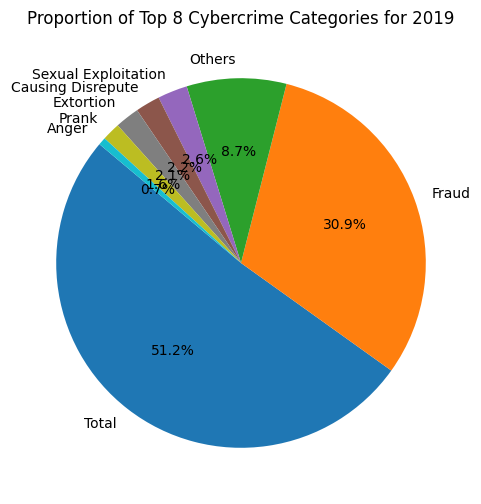

In [ ]:
# Summing up cybercrime types across all states
crime_sums = df.iloc[:, 3:].sum().sort_values(ascending=False)

# Plot pie chart for top 10 cybercrime categories
plt.figure(figsize=(15, 6))
crime_sums[:8].plot(kind="pie", autopct="%1.1f%%", cmap="tab10", startangle=140)
plt.ylabel("")
plt.title("Proportion of Top 8 Cybercrime Categories for 2019")
plt.show()


<ipython-input-16-33fd5158dc8f>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_sorted["Total"], y=df_sorted["State/UT"], palette="viridis")


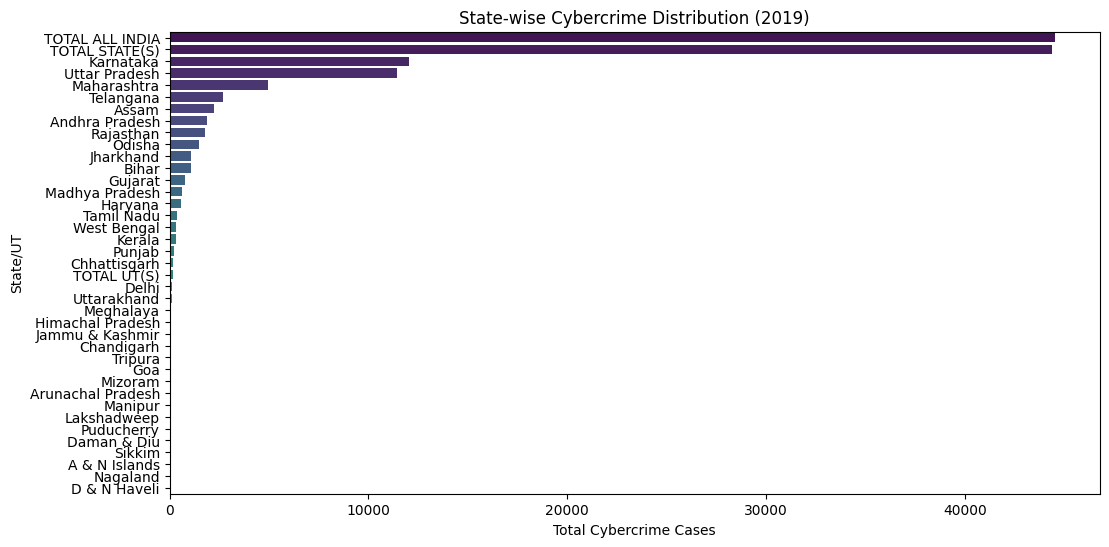

In [ ]:
df_sorted = df.sort_values(by="Total", ascending=False)

# Plotting the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=df_sorted["Total"], y=df_sorted["State/UT"], palette="viridis")
plt.xlabel("Total Cybercrime Cases")
plt.ylabel("State/UT")
plt.title("State-wise Cybercrime Distribution (2019)")
plt.show()

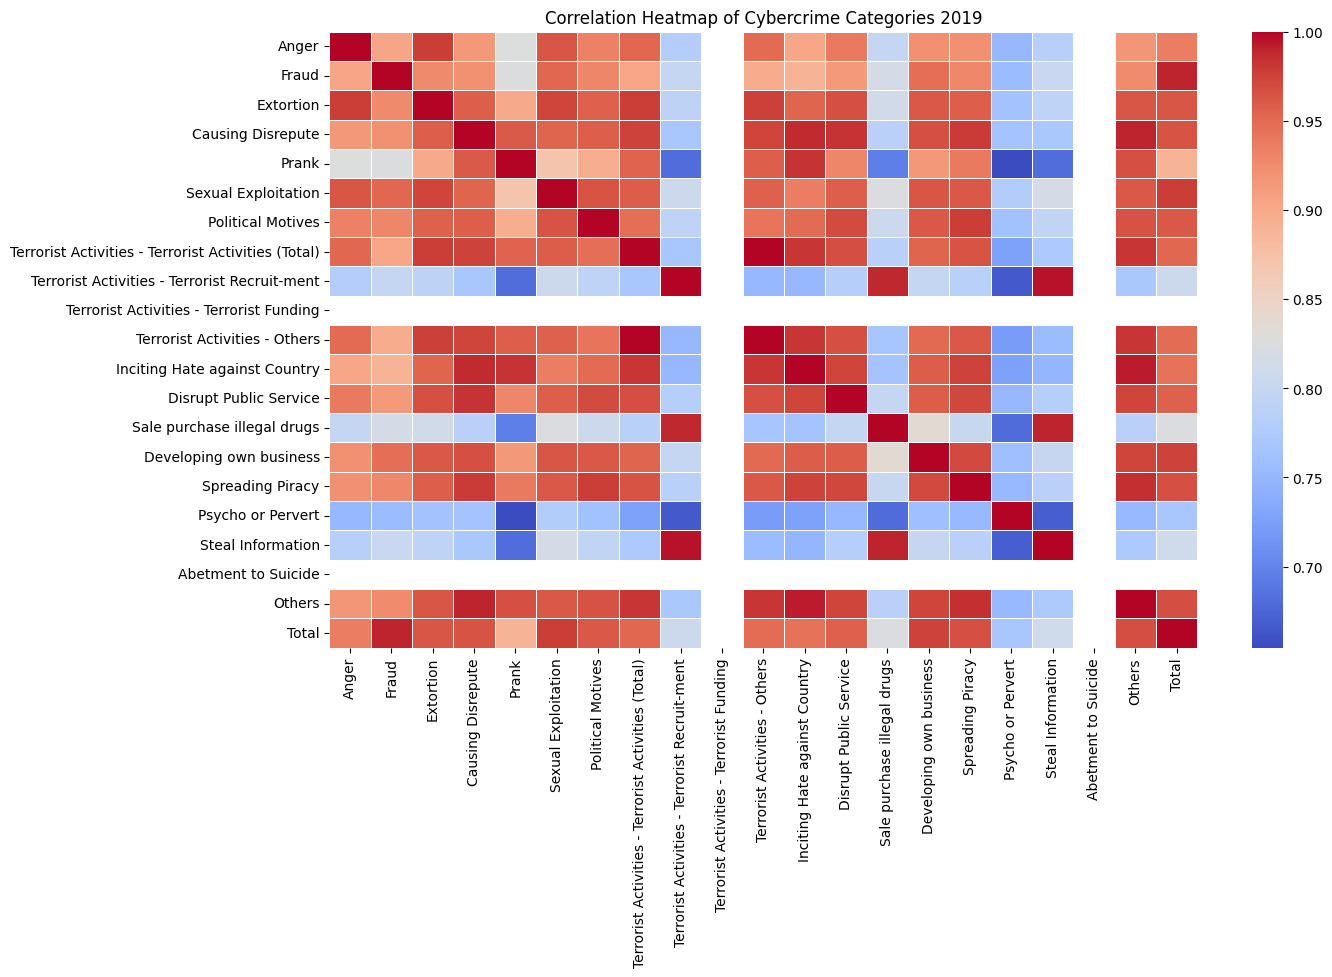

In [ ]:
# Compute correlation matrix
plt.figure(figsize=(14, 8))
corr_matrix = df.iloc[:, 3:].corr()  # Exclude non-numeric columns

# Plot heatmap
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Cybercrime Categories 2019")
plt.show()


<Figure size 1400x600 with 0 Axes>

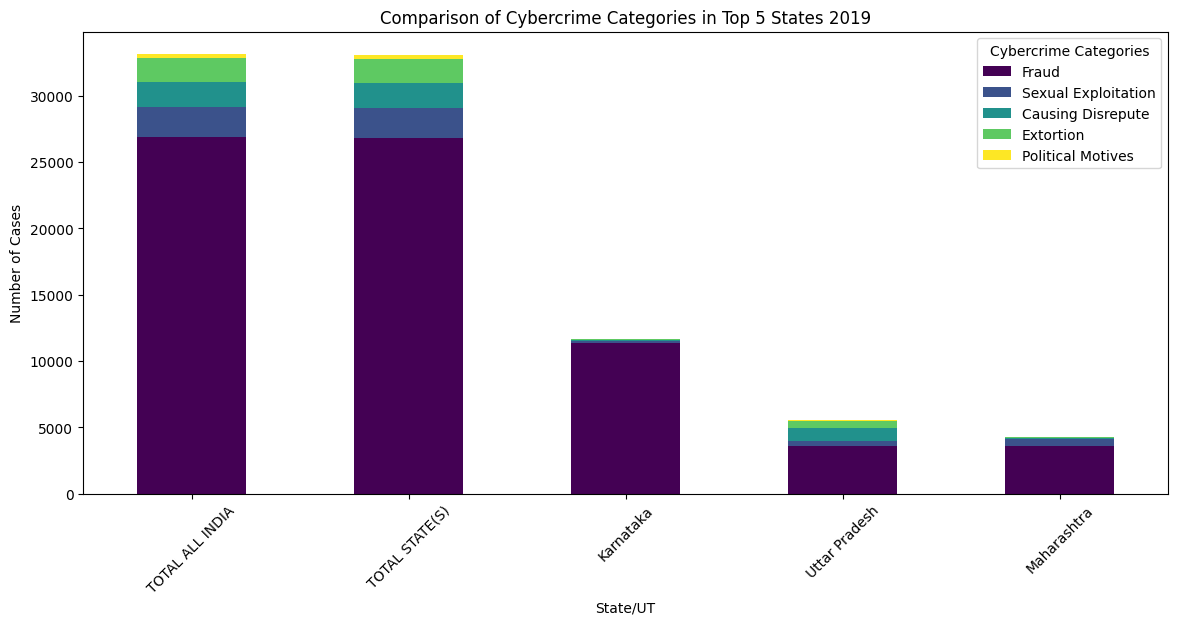

In [ ]:
# Selecting top 5 states with highest cybercrimes for visualization clarity
top_states = df.nlargest(5, "Total")

# Plot stacked bar chart
plt.figure(figsize=(14, 6))
top_states.set_index("State/UT")[["Fraud", "Sexual Exploitation", "Causing Disrepute", "Extortion", "Political Motives"]].plot(kind="bar", stacked=True, colormap="viridis", figsize=(14,6))

plt.xlabel("State/UT")
plt.ylabel("Number of Cases")
plt.title("Comparison of Cybercrime Categories in Top 5 States 2019")
plt.legend(title="Cybercrime Categories")
plt.xticks(rotation=45)
plt.show()


<Figure size 1000x600 with 0 Axes>

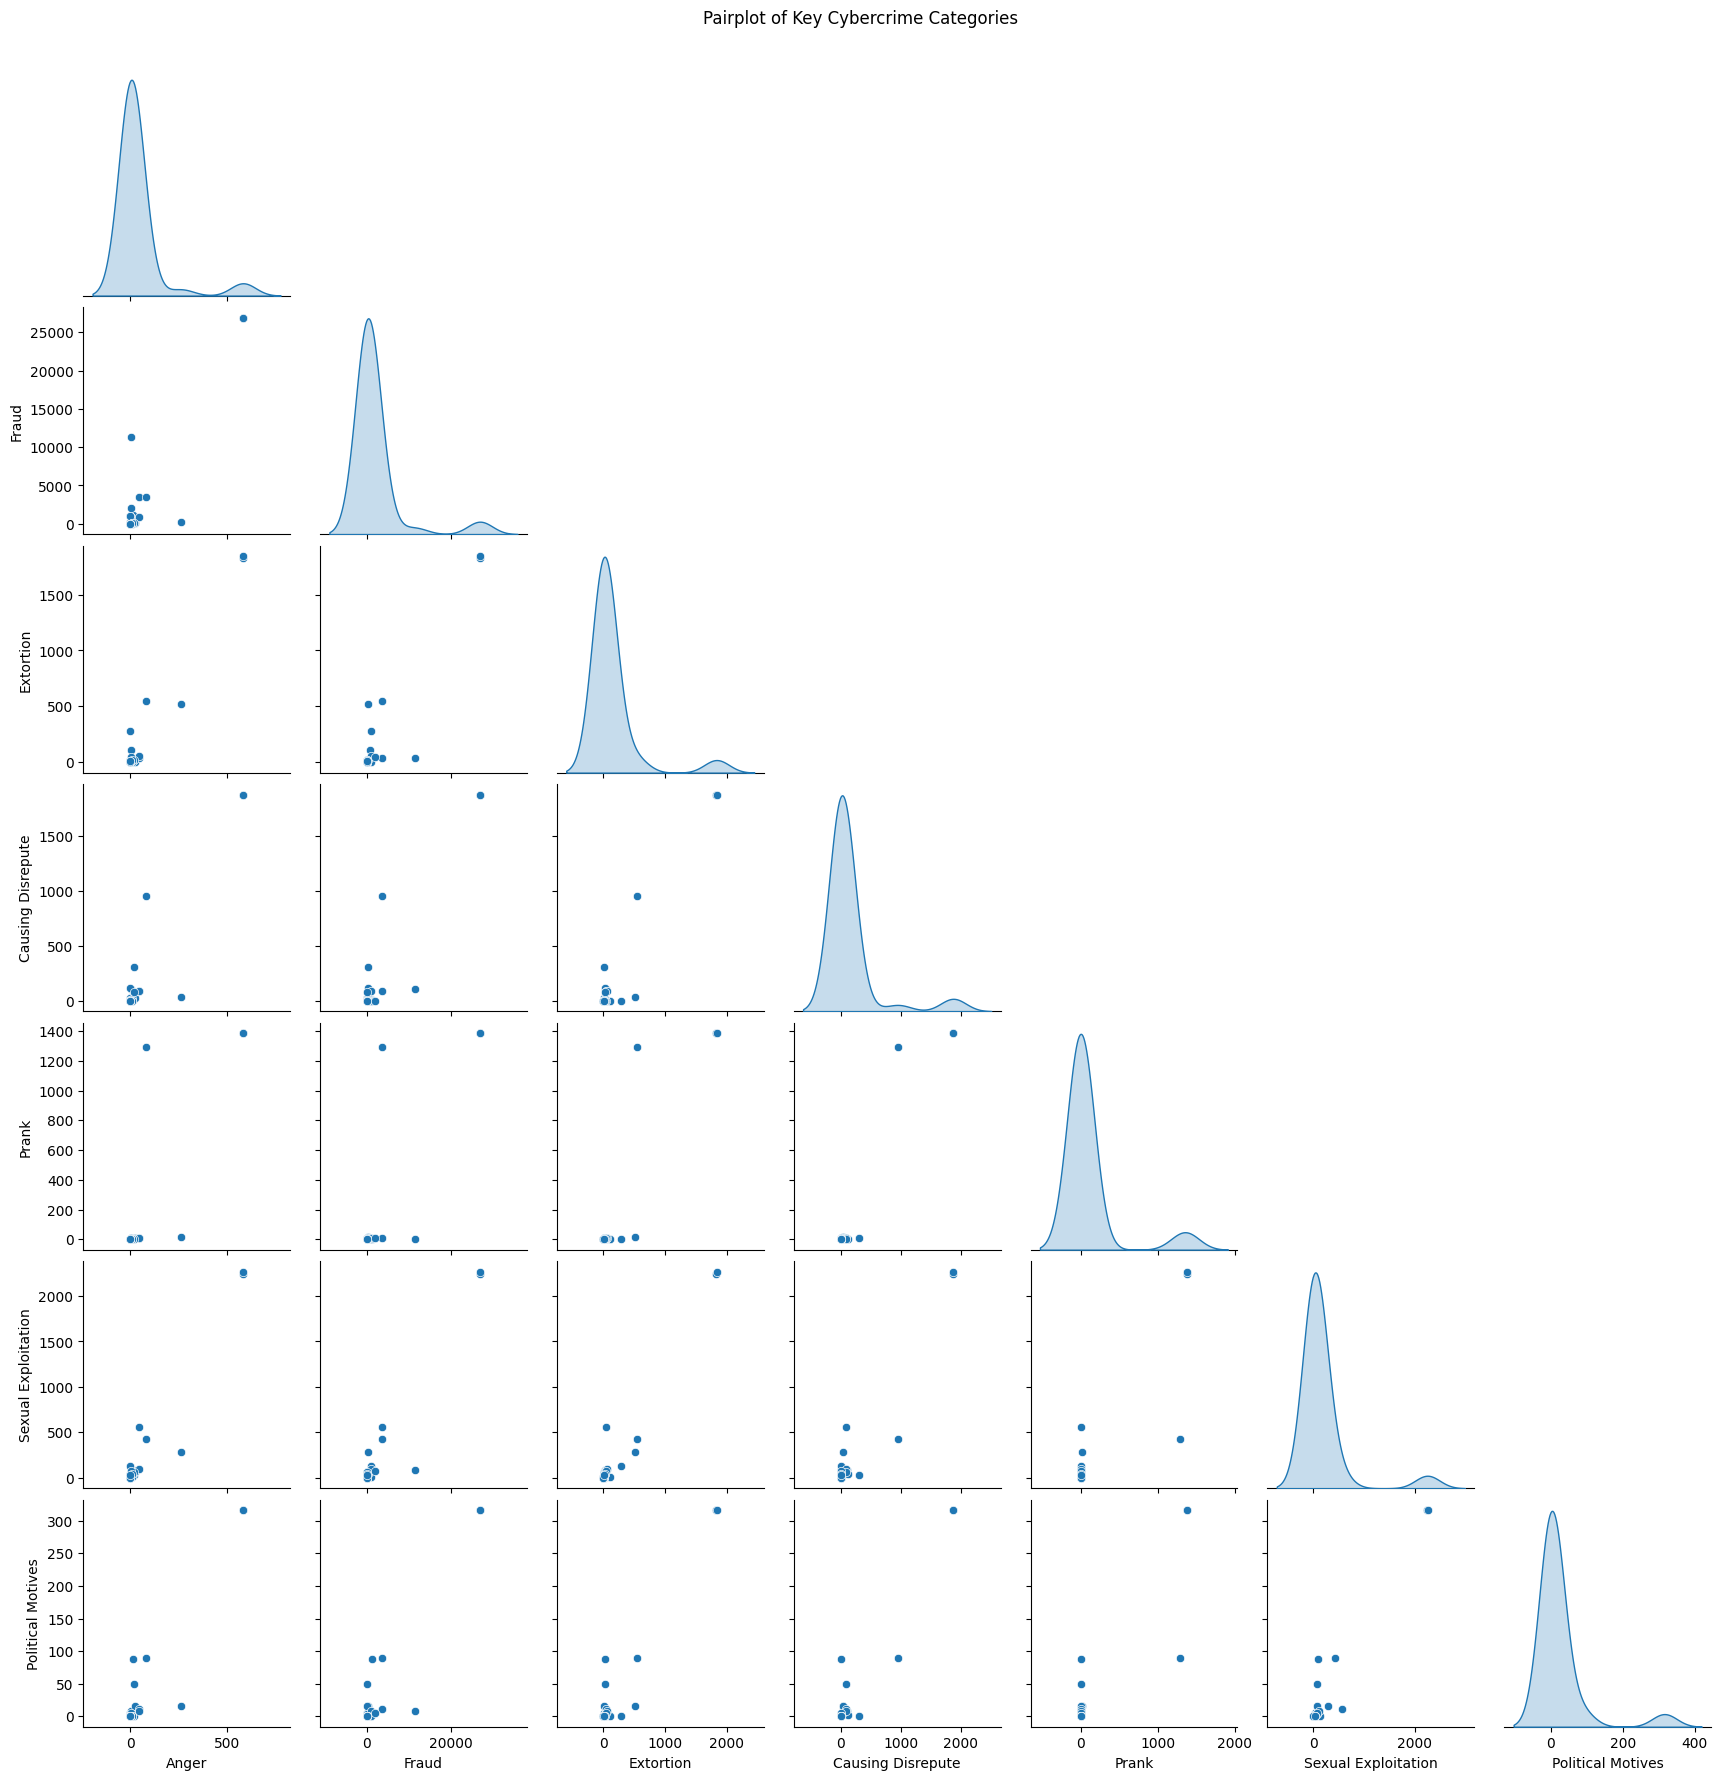

In [ ]:
# Pairplot to visualize relationships between different cybercrime categories
plt.figure(figsize=(10, 6))
sns.pairplot(df.iloc[:, 3:10], diag_kind="kde", corner=True)  # Selecting a subset for clarity
plt.suptitle("Pairplot of Key Cybercrime Categories", y=1.02)
plt.show()


In [ ]:
# Load the dataset
file_path = "/content/NCRB_CII-2020_Table.No-9A.3.csv"
df = pd.read_csv(file_path)

# Display basic information about the dataset
df.info(), df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 25 columns):
 #   Column                                                           Non-Null Count  Dtype 
---  ------                                                           --------------  ----- 
 0   Si. No (Col. 1)                                                  39 non-null     object
 1   Category                                                         39 non-null     object
 2   State/UT (Col. 2)                                                39 non-null     object
 3   Personal Revenge - (Col. 3)                                      39 non-null     int64 
 4   Anger - (Col. 4)                                                 39 non-null     int64 
 5   Fraud - (Col. 5)                                                 39 non-null     int64 
 6   Extortion - (Col. 6)                                             39 non-null     int64 
 7   Causing Disrepute - (Col. 7)                           

(None,
   Si. No (Col. 1) Category   State/UT (Col. 2)  Personal Revenge - (Col. 3)  \
 0               1     State     Andhra Pradesh                           83   
 1               2     State  Arunachal Pradesh                            1   
 2               3     State              Assam                          654   
 3               4     State              Bihar                           84   
 4               5     State       Chhattisgarh                            0   
 
    Anger - (Col. 4)  Fraud - (Col. 5)  Extortion - (Col. 6)  \
 0                39              1149                    56   
 1                 0                26                     0   
 2               164               242                   447   
 3                34              1218                   102   
 4                 1                75                     7   
 
    Causing Disrepute - (Col. 7)  Prank - (Col. 8)  \
 0                            15                 2   
 1               

In [ ]:
# Renaming columns for better readability
df.rename(columns={
    "S. No (Col.1)": "S_No",
    "Category (Col.2)": "Category",
    "State/UT (Col.3)": "State_UT",
    "Personal Revenge (Col.4)": "Personal_Revenge",
    "Anger (Col.5)": "Anger",
    "Fraud (Col.6)": "Fraud",
    "Extortion (Col.7)": "Extortion",
    "Causing Disrepute (Col.8)": "Causing_Disrepute",
    "Prank (Col.9)": "Prank",
    "Sexual Exploitation (Col.10)": "Sexual_Exploitation",
    "Political Motives (Col.11)": "Political_Motives",
    "Terrorist Activities (Col.12= Col.13+Col.14+Col.15)": "Terrorist_Activities",
    "Terrorist Activities - Terrorist Recruitment (Col.13)": "Terrorist_Recruitment",
    "Terrorist Activities - Terrorist Funding (Col.14)": "Terrorist_Funding",
    "Terrorist Activities - Others (Col.15)": "Terrorist_Others",
    "Inciting Hate against Country (Col.16)": "Inciting_Hate",
    "Disrupt Public Service (Col.17)": "Disrupt_Public_Service",
    "Sale Purchase Illegal Drugs (Col.18)": "Illegal_Drug_Sale",
    "Developing own Business (Col.19)": "Developing_Business",
    "Spreading Piracy (Col.20)": "Spreading_Piracy",
    "Psycho or Pervert (Col.21)": "Psycho_Pervert",
    "Steal Information (Col.22)": "Steal_Information",
    "Abetment to Suicide (Col.23)": "Abetment_to_Suicide",
    "Others (Col.24)": "Others",
    "Total (Col.25=Col.1+Col.2+Col.3+Col.4Col.5+Col.6+Col.7+Col.8+Col.9+Col.10+Col.11+Col.12+Col.15+Col.16+Col.17+Col.18+Col.19+Col.20+Col.21+Col.22+Col.23+Col.24": "Total"
}, inplace=True)

# Checking the updated column names
df.head()


,Si. No (Col. 1),Category,State/UT (Col. 2),Personal Revenge - (Col. 3),Anger - (Col. 4),Fraud - (Col. 5),Extortion - (Col. 6),Causing Disrepute - (Col. 7),Prank - (Col. 8),Sexual Exploitation - (Col. 9),...,Inciting Hate against Country - (Col. 15),Disrupt Public Service - (Col. 16),Sale Purchase illegal drugs - (Col. 17),Developing own business - (Col. 18),Spreading Piracy - (Col. 19),Psycho or Pervert - (Col. 20),Steal Information - (Col. 21),Abetment to Suicide - (Col. 22),Others - (Col. 23),Total - (Col. 24)
0,1,State,Andhra Pradesh,83,39,1149,56,15,2,169,...,0,2,0,42,0,0,4,0,271,1899
1,2,State,Arunachal Pradesh,1,0,26,0,0,0,0,...,0,0,0,0,0,0,2,0,1,30
2,3,State,Assam,654,164,242,447,85,35,483,...,58,12,0,3,0,0,0,0,1323,3530
3,4,State,Bihar,84,34,1218,102,19,12,32,...,0,1,0,3,0,0,0,0,0,1512
4,5,State,Chhattisgarh,0,1,75,7,41,0,35,...,0,0,0,1,0,0,0,0,135,297


In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]


,0


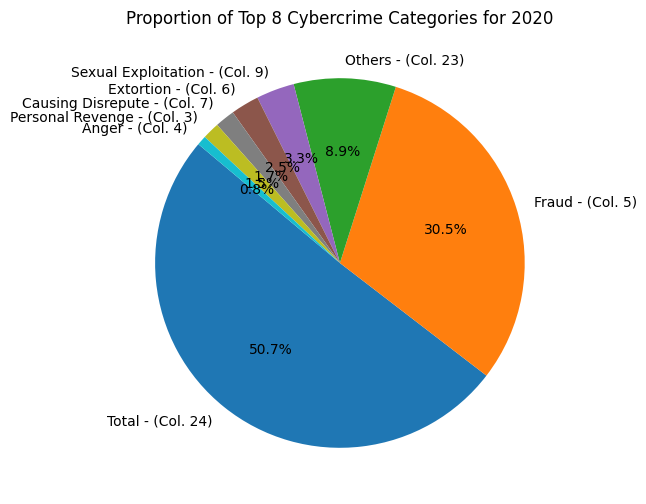

In [ ]:
# Summing up cybercrime types across all states
crime_sums = df.iloc[:, 3:].sum().sort_values(ascending=False)

# Plot pie chart for top 10 cybercrime categories
plt.figure(figsize=(15, 6))
crime_sums[:8].plot(kind="pie", autopct="%1.1f%%", cmap="tab10", startangle=140)
plt.ylabel("")
plt.title("Proportion of Top 8 Cybercrime Categories for 2020")
plt.show()


<ipython-input-28-0bf40d1d0ac7>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_sorted["Total - (Col. 24)"], y=df_sorted["State/UT (Col. 2)"], palette="viridis")


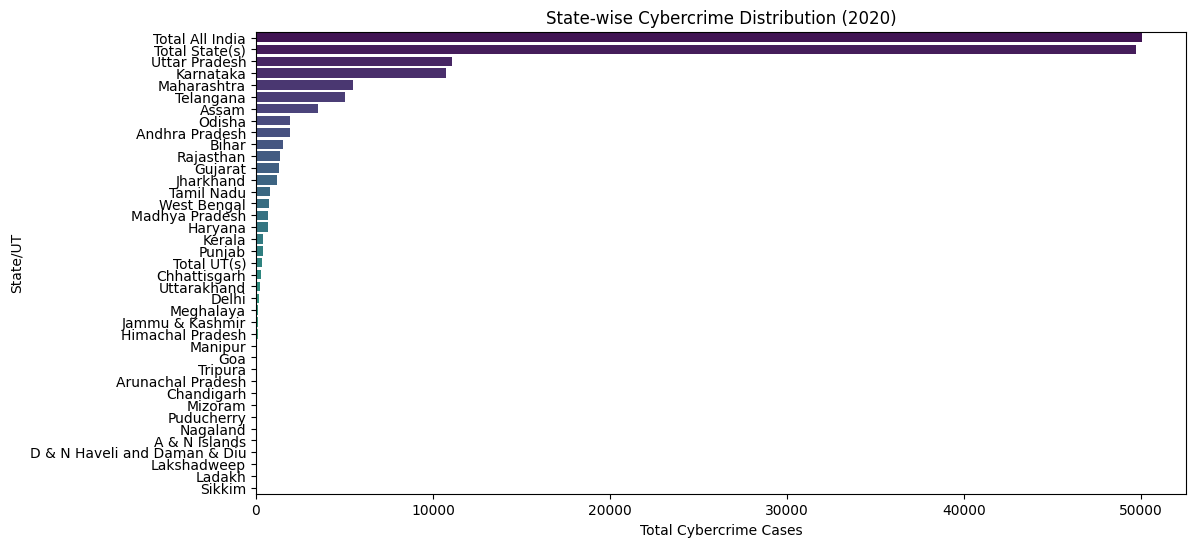

In [ ]:
df_sorted = df.sort_values(by="Total - (Col. 24)", ascending=False)

# Plotting the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=df_sorted["Total - (Col. 24)"], y=df_sorted["State/UT (Col. 2)"], palette="viridis")
plt.xlabel("Total Cybercrime Cases")
plt.ylabel("State/UT")
plt.title("State-wise Cybercrime Distribution (2020)")
plt.show()

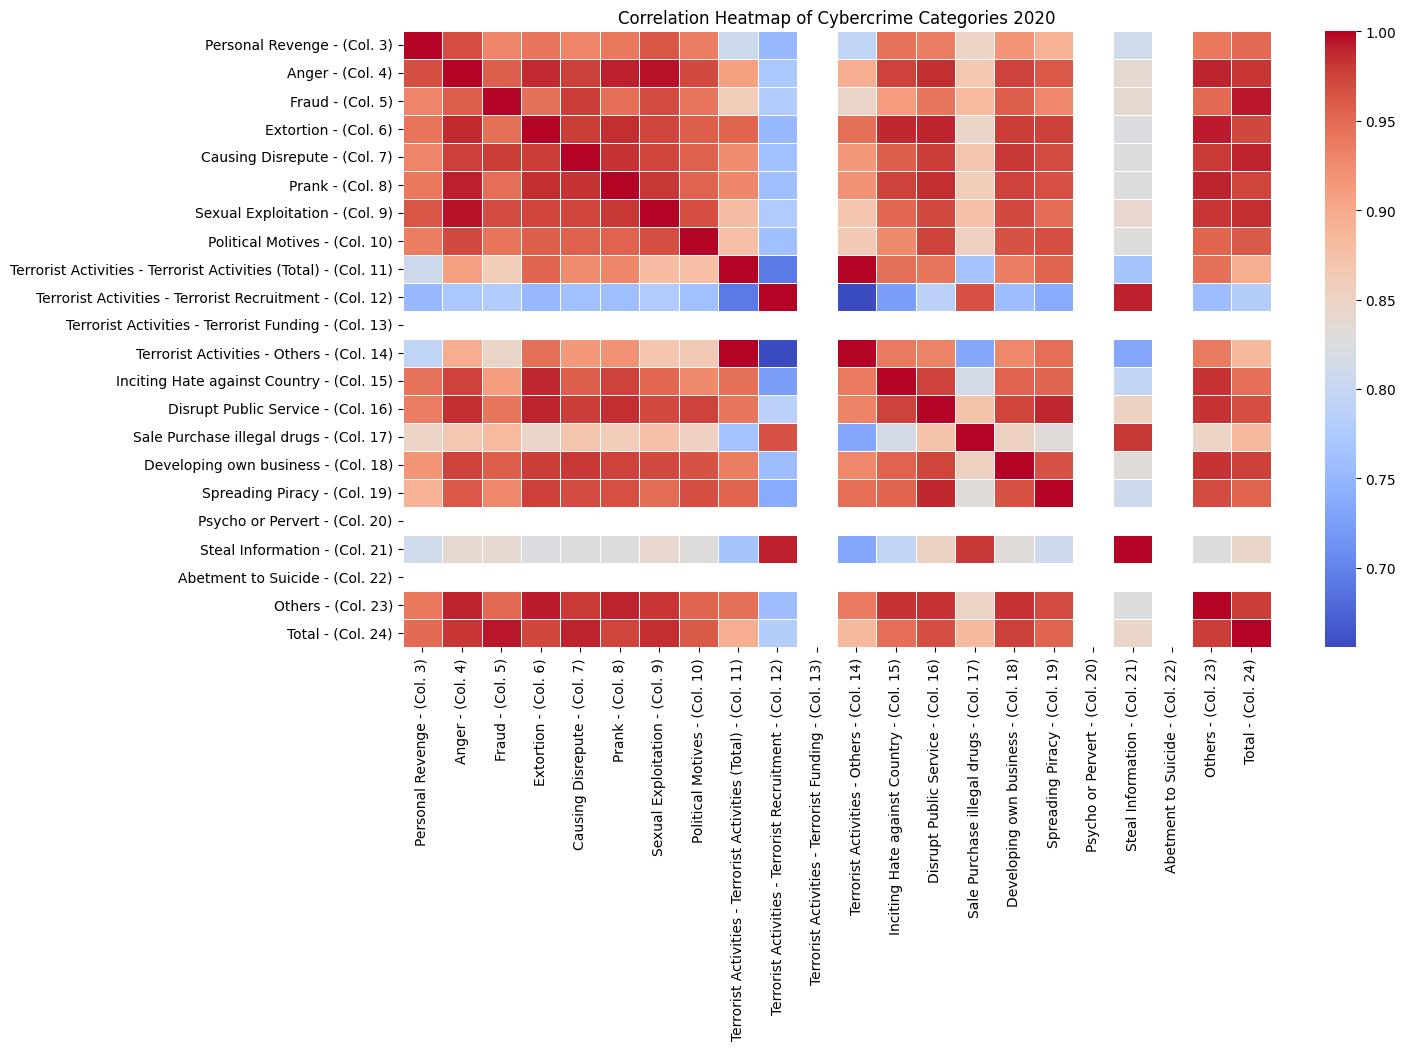

In [ ]:
# Compute correlation matrix
plt.figure(figsize=(14, 8))
corr_matrix = df.iloc[:, 3:].corr()  # Exclude non-numeric columns

# Plot heatmap
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Cybercrime Categories 2020")
plt.show()


<Figure size 1400x600 with 0 Axes>

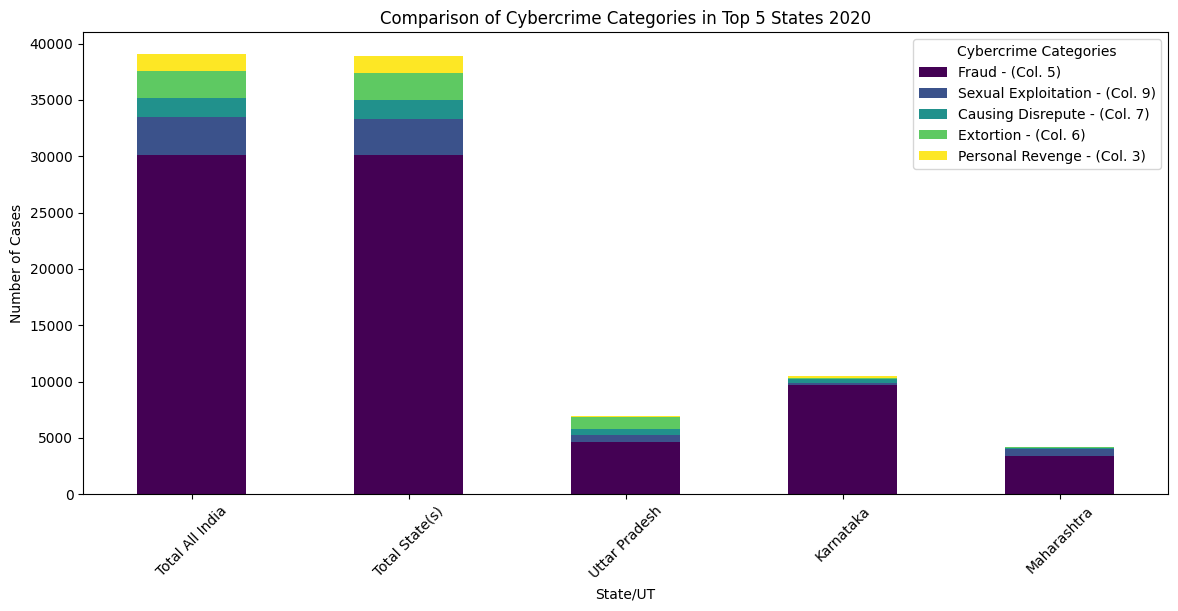

In [ ]:
# Selecting top 5 states with highest cybercrimes for visualization clarity
top_states = df.nlargest(5, "Total - (Col. 24)")

# Plot stacked bar chart
plt.figure(figsize=(14, 6))
top_states.set_index("State/UT (Col. 2)")[["Fraud - (Col. 5)", "Sexual Exploitation - (Col. 9)", "Causing Disrepute - (Col. 7)", "Extortion - (Col. 6)", "Personal Revenge - (Col. 3)"]].plot(kind="bar", stacked=True, colormap="viridis", figsize=(14,6))

plt.xlabel("State/UT")
plt.ylabel("Number of Cases")
plt.title("Comparison of Cybercrime Categories in Top 5 States 2020")
plt.legend(title="Cybercrime Categories")
plt.xticks(rotation=45)
plt.show()


<Figure size 1000x600 with 0 Axes>

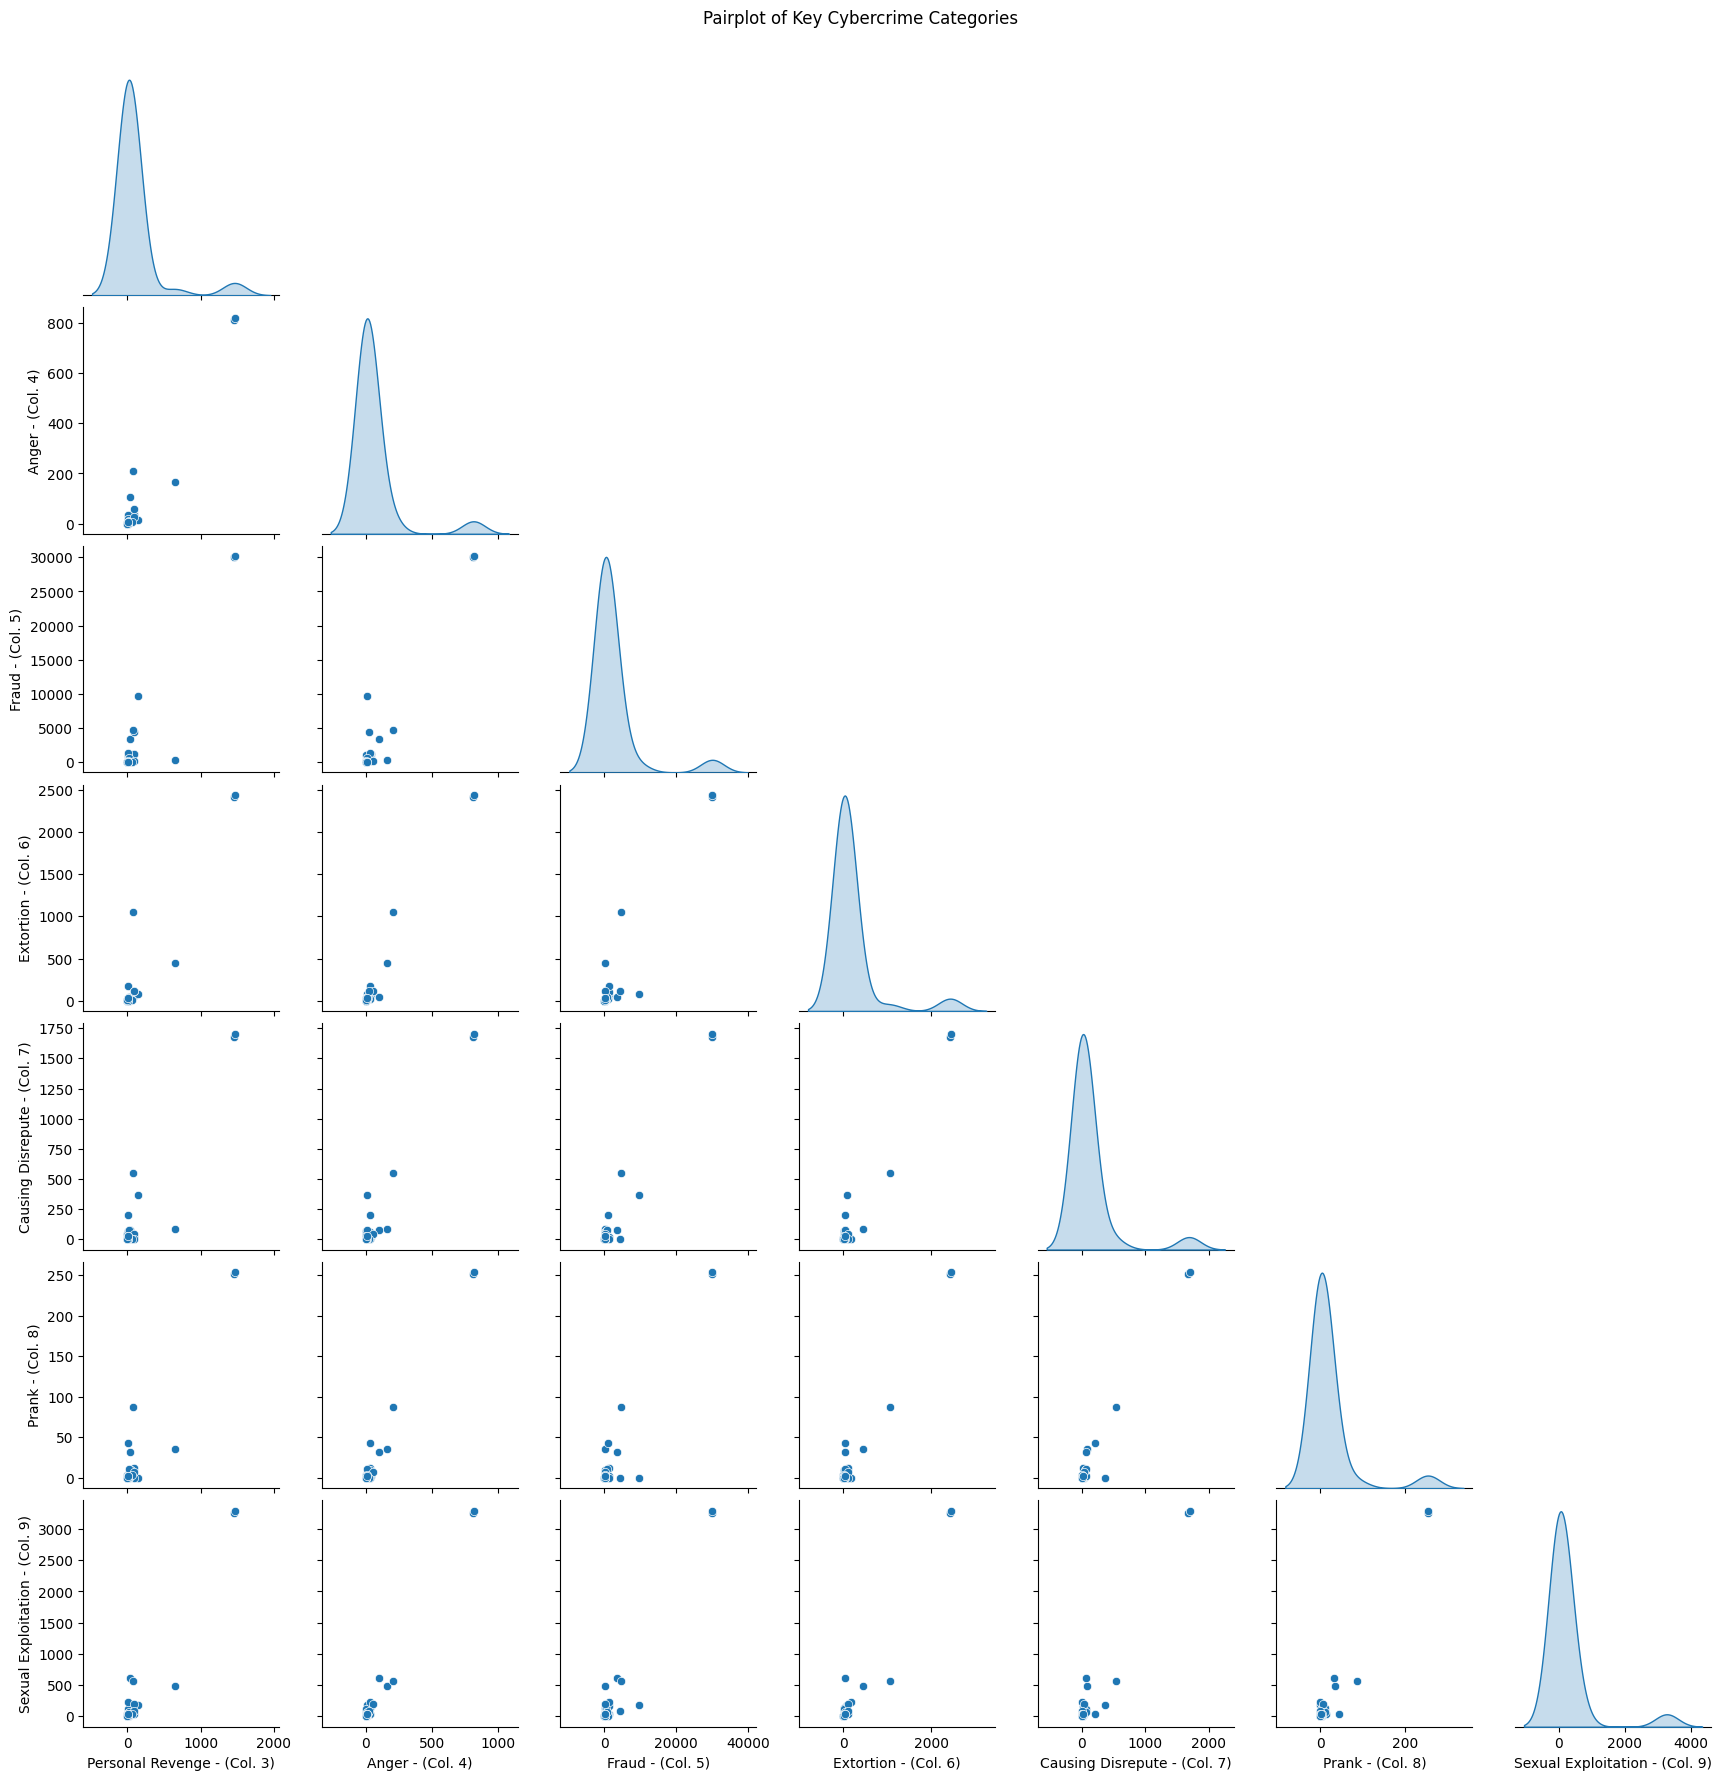

In [ ]:
# Pairplot to visualize relationships between different cybercrime categories
plt.figure(figsize=(10, 6))
sns.pairplot(df.iloc[:, 3:10], diag_kind="kde", corner=True)  # Selecting a subset for clarity
plt.suptitle("Pairplot of Key Cybercrime Categories", y=1.02)
plt.show()
